## Gráficos para la presentación

In [26]:
"""
Carga de datos
"""
# Importa todas las bibliotecas necesarias para este NoteBook
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
from EDA_helpers import (load_tables,
                         categorizar_ausentismo,
                         categorizar_ausencias,
                         categorizar_distancias)

# Paleta de colores Seaborn Set2, para usarla con MatPlotLib y seguir el mismo estilo
sns_color_set2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
colores        = sns_color_set2
tablas_db      = ['ausentismo', 'long_absence']

df = load_tables(tablas_db)

df_ausentismo, df_niveles = [df['ausentismo'], df['long_absence']]

abs_levels   = ['Bajo', 'Medio', 'Alto', 'Muy alto']
laboral_vars = ['disciplined', 'Hit_target', 'work_load_avg', 'Service_time', 'work_days_absent']
social_selct = ['Education', 'tr_expense','Social_smoker', 'Social_drinker','work_days_absent']
social_vars  = ['Age',
                'Education',
                'weight',
                'height',
                'tr_expense',
                'children',
                'bmi',
                'dist2work',
                'Social_smoker',
                'Social_drinker',
                'work_days_absent']

# Categorizar las columnas Month_absence, Day_of_week y Season.
df_ausentismo = categorizar_ausentismo(df_ausentismo)
# Clasificar las ausencias en dos categorías (Justificada / Injustificada)
df_ausentismo = categorizar_ausencias(df_ausentismo)
# Clasificar las distancias al trabajo, en franjas de kms.
df_ausentismo = categorizar_distancias(df_ausentismo)

df_ausentismo['Age Group']    = df_ausentismo['Group']
df_ausentismo['Absence_type'] = np.where(
    df_ausentismo['reason_id'].isin([0, 26]),
    'Unjustified',
    'Justified'
)

df_integrado = df_ausentismo.merge(df_niveles, left_on='id', right_on='ID', how='inner')
df_socials   = df_integrado[social_vars]
df_laboral   = df_integrado[laboral_vars]
perfiles     = df_niveles.groupby('level', observed=False)['ID'].count().sort_values(ascending=False)

# Perfiles de empleados con nivel de absentismo "Muy alto"
perfiles_altos = df_niveles.loc[df_niveles['level'].isin(['Muy alto', 'Alto', 'Medio'])]

# Tabla cruzada para analizar los perfiles de riesgo de empleados y niveles de absentismo
cantidad_dias  = df_niveles.groupby('level')['work_days_absent'].sum().sort_values(ascending=False)

df_filtrado = df_integrado[df_integrado['ID'].isin(perfiles_altos['ID'])]
df_filtrado['level'] = 'Alto'

Cargando los datos de la tabla ausentismo
Cargando los datos de la tabla long_absence


#### Visualizaciones por variables categóricas y numéricas

#### Correlación de variables sociales / personales
Veamos la relación entre las variables que consideramos personales.

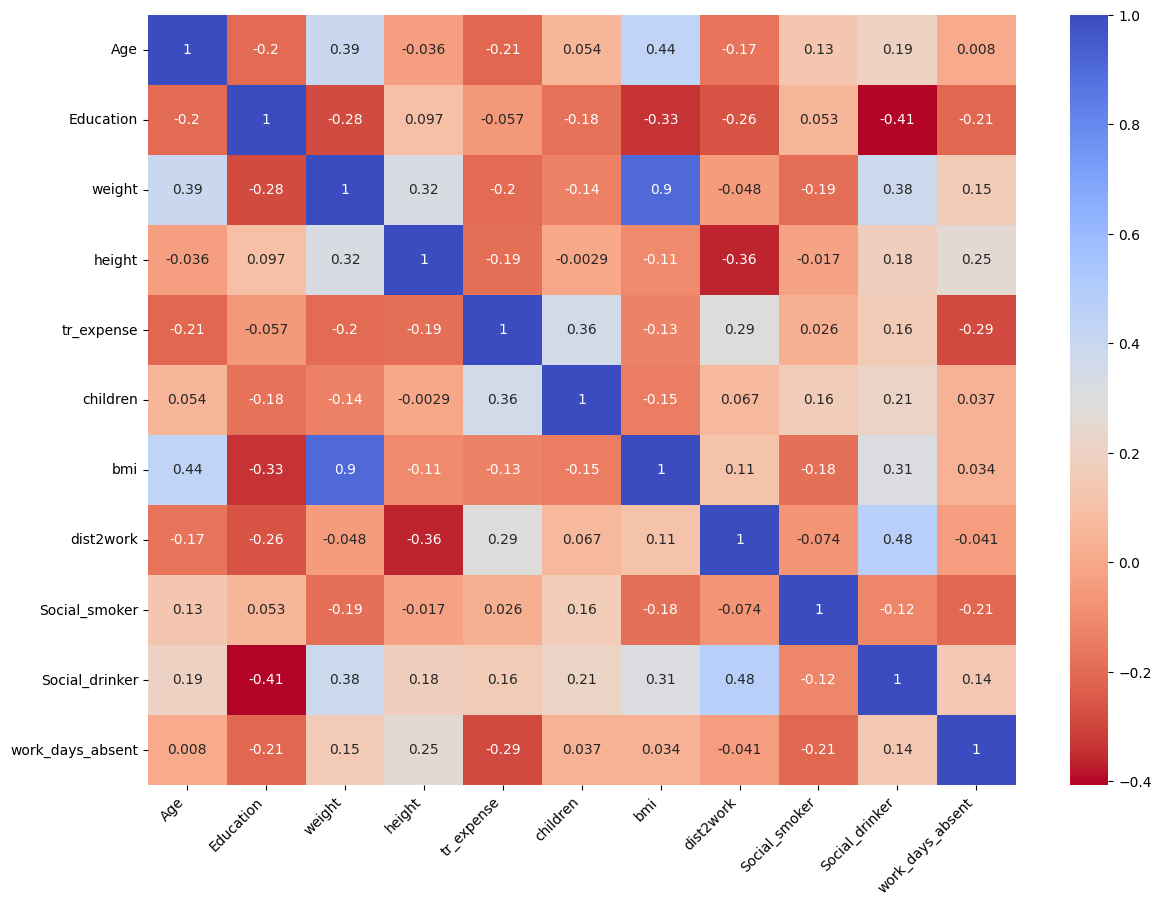

In [10]:
cr = df_socials.corr()
filteredDf = cr[((cr >= .5) | (cr <= -.5)) & (cr !=1.000)]
plt.figure(figsize=(14,10))
sns.heatmap(cr, annot=True, cmap="coolwarm_r")
plt.xticks(rotation=45, ha='right');

Resumen del mapa de calor: nos interesan las horas de ausencia, y vemos que los valores por encima de ±0.3 son la educación (inversa), el gasto en transporte (curiosamente inverso, también) y el fumador social. El resto no presenta una correlación significativa.

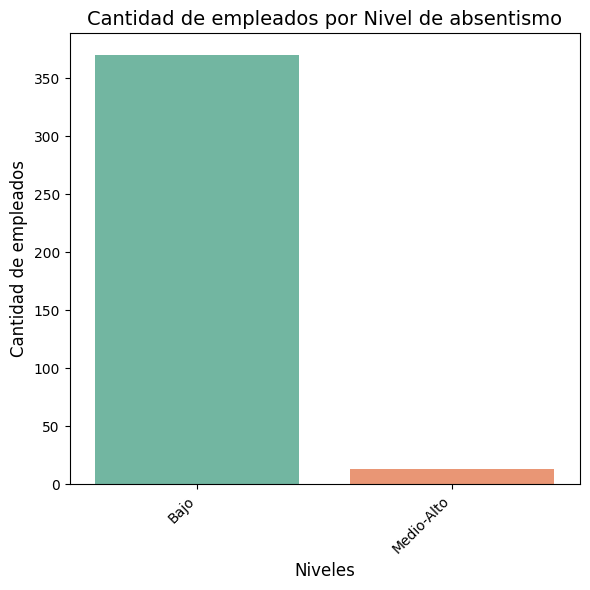

In [11]:
# Gráfico de barras para cuantificar los niveles de absentismo por cantidad de empleados
# Crear el gráfico de barras
plt.figure(figsize=(6, 6))
sns.barplot(
    x=perfiles.index,
    y=perfiles.values,
    palette='Set2',
    hue=perfiles.index,
    legend=False
)

# Añadir etiquetas y título
plt.title('Cantidad de empleados por Nivel de absentismo', fontsize=14)
plt.xlabel('Niveles', fontsize=12)
plt.ylabel('Cantidad de empleados', fontsize=12)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()

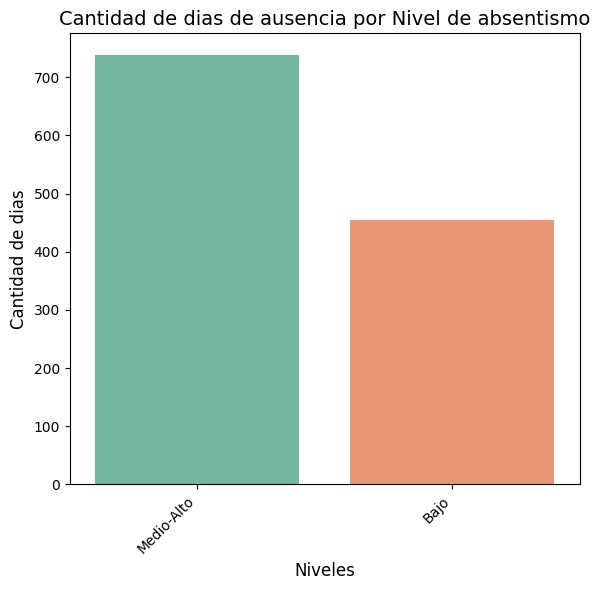

In [ ]:
# Gráfico de barras para cuantificar la cantidad de dias de absentismo por niveles ordinales
# Crear el gráfico de barras
plt.figure(figsize=(6, 6))
sns.barplot(
    x=cantidad_dias.index,
    y=cantidad_dias.values,
    palette='Set2',
    hue=perfiles.index,
    legend=False
)

# Añadir etiquetas y título
plt.title('Cantidad de dias de ausencia por Nivel de absentismo', fontsize=14)
plt.xlabel('Niveles', fontsize=12)
plt.ylabel('Cantidad de dias', fontsize=12)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()



Tras analizar varias de las variables en ambos grupos (personal y laboral), seleccionamos algunas de las variables con alguna, mínima, relación.

In [16]:
df_laboral.head()

,disciplined,Hit_target,work_load_avg,Service_time,work_days_absent
0,0,97,284.031,14,105.50
1,0,98,239.409,18,78.88
2,0,93,264.604,16,90.75
3,0,92,230.290,9,71.38
4,0,99,222.196,16,90.75


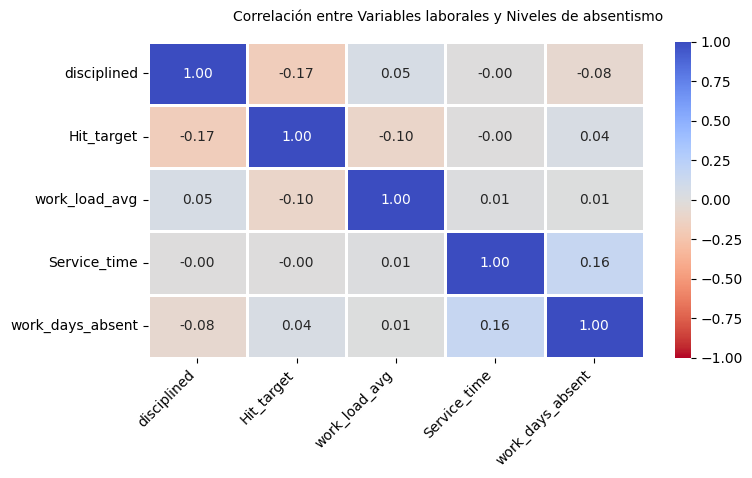

In [6]:
# Correlación de variables laborales con niveles de absentismo (work_days_absent)

# Calculamos la correlación entre las variables laborales y los niveles de absentismo.
correlation = df_laboral.corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables laborales y Niveles de absentismo', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.show()


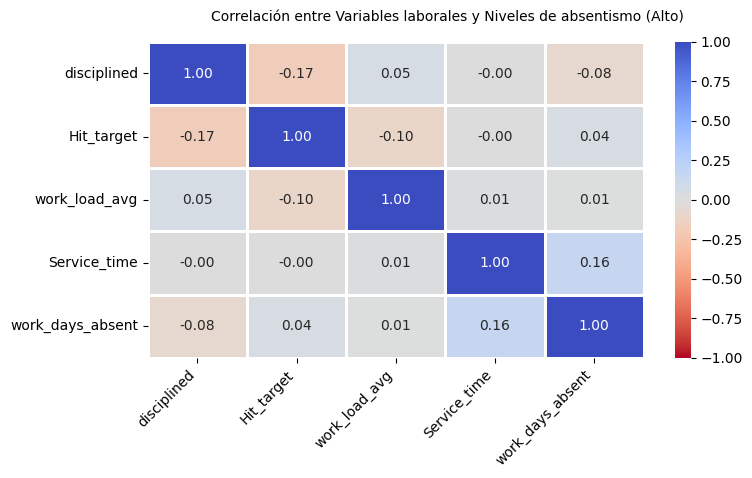

In [25]:
# Correlación de variables laborales con niveles de absentismo (Alto)
# Calculamos la correlación entre las variables laborales seleccionadas y los niveles de absentismo.
correlation = df_laboral[laboral_vars].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables laborales y Niveles de absentismo (Alto)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.show()

In [21]:
df_socials

,Age,Education,weight,height,tr_expense,children,bmi,dist2work,Social_smoker,Social_drinker,work_days_absent
0,34,1,95,196,155,2,25,12,0,1,105.50
1,50,1,98,178,118,1,31,13,0,1,78.88
2,58,1,65,172,228,2,22,14,0,0,90.75
3,28,1,69,169,225,1,24,26,0,0,71.38
4,58,1,65,172,228,2,22,14,0,0,90.75
...,...,...,...,...,...,...,...,...,...,...,...
1101,30,3,56,171,179,0,19,26,0,0,39.63
1102,43,1,77,175,300,2,25,26,1,1,18.38
1103,37,1,83,172,118,0,28,10,0,0,58.00
1104,36,1,65,168,260,4,23,50,0,1,45.25


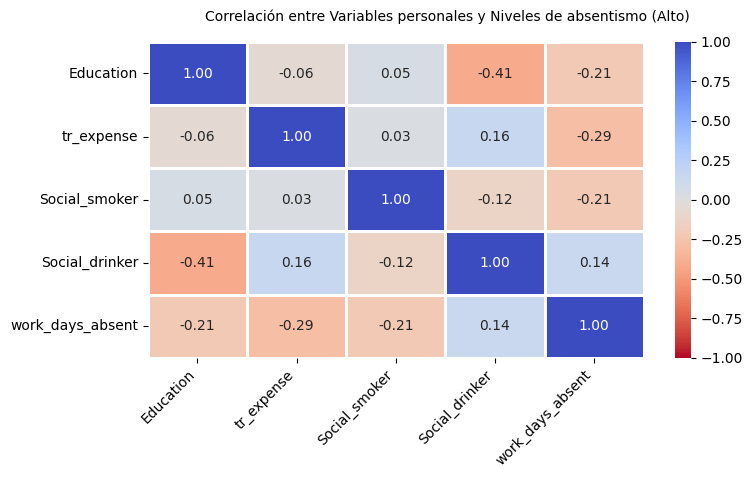

In [27]:
# Correlación de variables personales con niveles de absentismo (Alto)

# Calculamos la correlación entre las variables personales y los niveles de absentismo.
correlation2 = df_socials[social_selct].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation2, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables personales y Niveles de absentismo (Alto)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.show()

Incluso un análisis binomial nos dice que la relación es inexistente.

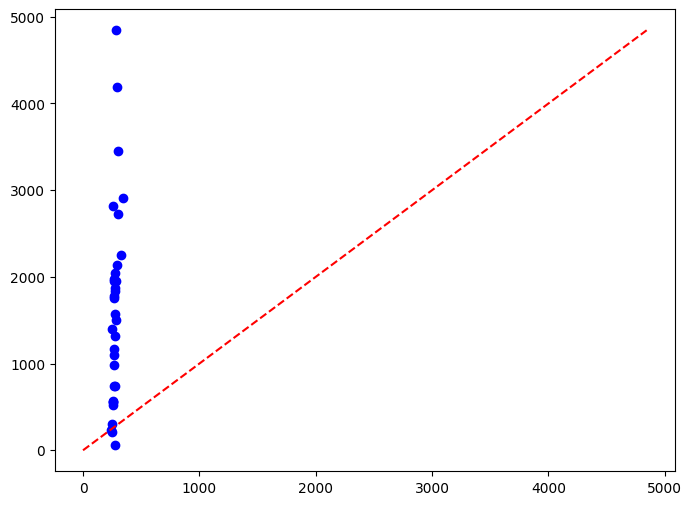

In [30]:
df_vars = df_integrado[['id'] + ['Education', 'tr_expense', 'Social_drinker','Service_time','work_load_avg','work_days_absent']] \
            .drop_duplicates()
df_agg = df_vars.groupby('id')['work_load_avg'].agg(['mean', 'var'])
plt.figure(figsize=(8, 6))
plt.scatter(df_agg['mean'], df_agg['var'], color='blue')
max_val = max(df_agg['mean'].max(), df_agg['var'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Línea de Poisson (Varianza = Media)');
